# <center> Практические задания по цифровой обработке сигналов </center>
# <center> Первая лабораторная работа </center>


В данной работе Вы познакомитесь с основными методами работы с аудиоданными в Python. Разбересь в том, как работает свертка, и примените пару интересных фильтров.

# Задание 1. Работа с аудиофайлами в Python (1 балл)

## Теория

Звук - это аналоговый сигнал. То есть он является непрерывным по времени и по значениям. Для того, чтобы работать со звуком на цифровом устройстве, надо преобразовать его в цифровое представление. Для этого надо разделить непрерывный сигнал на промежутки времени (дискретизация сигнала) и разбить непрерывные значения на интервалы (квантование сигнала). Выбраные параметры дискретизации и квантования сигнала напрямую влияют на качество цифрового сигнала. 

<!-- 
## Практика

1. Что хранится в .wav файле? Как узнать параметры дискретизации и квантования .wav файла? 

2. Запишите аудиофайл со своим голосом. Загрузите его. Попробуйте поменять ему частоту дискретизации. Нарисуйте форму волны считанного файла. Воспроизведите полученные сигналы. При какой частоте дискретизации становится невозможно разобрать человеческую речь?   

3. Чем .wav отличается от других кодеков, например .mp3 или .ogg? -->


<!-- ### Подсказка

Записать цифровой сигнал можно при помощи, например, [Audacity](https://www.audacityteam.org) или [Adobe Audition](https://www.adobe.com/ru/products/audition.html). Для считывания файлов воспользуйтесь библиотекой [scipy](https://www.scipy.org) или [librosa](https://librosa.org/doc/latest/index.html). Для воспроизведения аудиофайла удобно использовать класс Audio из модуля IPython.display, а для отрисовки - matplotlib. -->

In [233]:
import matplotlib.pyplot as plt 
import numpy as np
import scipy.signal 
%matplotlib inline

### 1. Что хранится в .wav файле? Как узнать параметры дискретизации и квантования .wav файла?

В файле формата WAV (Waveform Audio File Format) хранятся данные оцифрованных аудиосигналов. Формат использует несжатую запись аудиоданных, где каждый отсчёт сигнала сохраняется в виде числа. Это обеспечивает максимальную точность воспроизведения, но требует значительного объёма дискового пространства.

Структура
Файл WAV включает несколько компонентов: 

* Заголовок RIFF — содержит информацию о размере файла.
* Форматный блок — описывает параметры кодирования.
* Блок данных — где хранятся сами аудиоданные.
* Дополнительные метаданные (при необходимости).

Параметры дискретизации и квантования в файле WAV указываются в заголовке. Например, в заголовке могут быть указаны: 

* Количество каналов — моно (1) или стерео (2). 
* Количество байт, переданных за секунду воспроизведения. 
* Количество байт для одного сэмпла, включая все
* Количество бит в сэмпле (эту величину ещё называют глубиной звучания)

In [223]:
from scipy.io import wavfile

sample_rate, data = wavfile.read("content/bach_orig.wav")
num_samples = len(data)             # количество отсчётов
bit_depth = data.itemsize * 8       # глубина квантования (в битах)
print("Параметры WAV файла")
print(f"Частота дискретизации: {sample_rate} Гц")
print(f"Количество отсчётов: {num_samples}")
print(f"Глубина квантования: {bit_depth} бит")


Параметры WAV файла
Частота дискретизации: 44100 Гц
Количество отсчётов: 1886512
Глубина квантования: 16 бит


### 2. Запишите аудиофайл со своим голосом. Загрузите его. Попробуйте поменять ему частоту дискретизации. Нарисуйте форму волны считанного файла. Воспроизведите полученные сигналы. При какой частоте дискретизации становится невозможно разобрать человеческую речь?

**Подсказка**

Записать цифровой сигнал можно при помощи, например, [Audacity](https://www.audacityteam.org) или [Adobe Audition](https://www.adobe.com/ru/products/audition.html). Для считывания файлов воспользуйтесь библиотекой [scipy](https://www.scipy.org) или [librosa](https://librosa.org/doc/latest/index.html). Для воспроизведения аудиофайла удобно использовать класс Audio из модуля IPython.display, а для отрисовки - matplotlib.

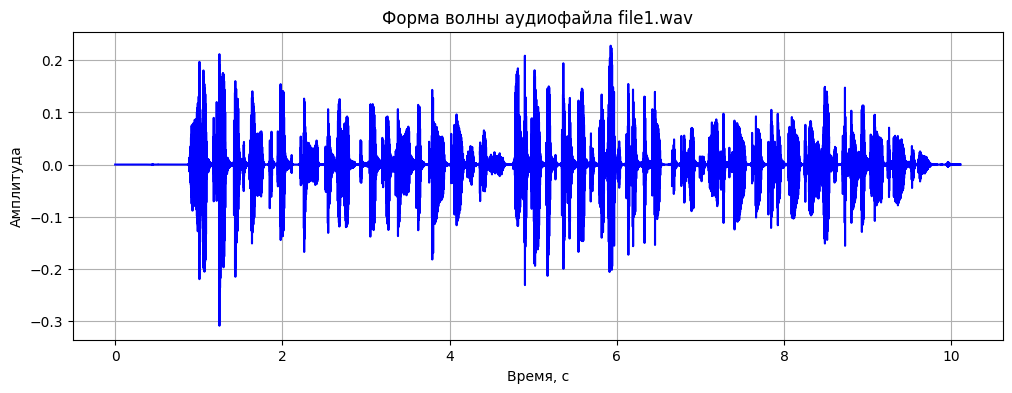

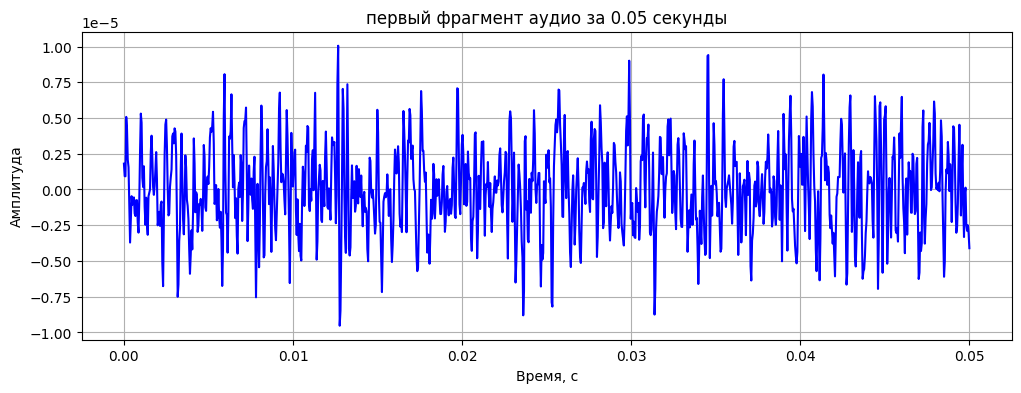

In [61]:
import librosa
from IPython.display import Audio

data, sample_rate = librosa.load("content/file1.wav")
Audio(data, rate=sample_rate)

# График формы волны
plt.figure(figsize=(12, 4))
time = np.linspace(0, len(data) / sample_rate, num=len(data))
plt.plot(time, data, color='blue')
plt.title("Форма волны аудиофайла file1.wav")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

# График для деатльного рассмотрения 
duration = 0.05  # секунды
num_samples = int(duration * sample_rate)
data_segment = data[:num_samples]

time = np.linspace(0, duration, num=num_samples)

plt.figure(figsize=(12, 4))
plt.plot(time, data_segment, color='blue')
plt.title("первый фрагмент аудио за 0.05 секунды")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

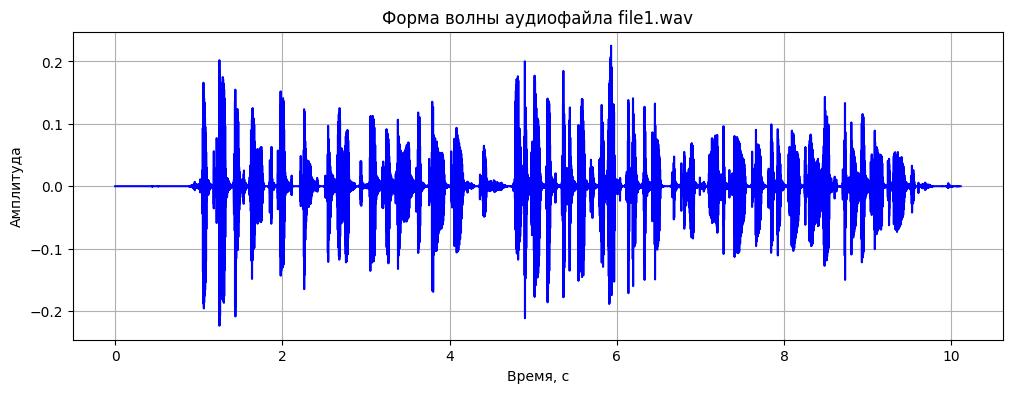

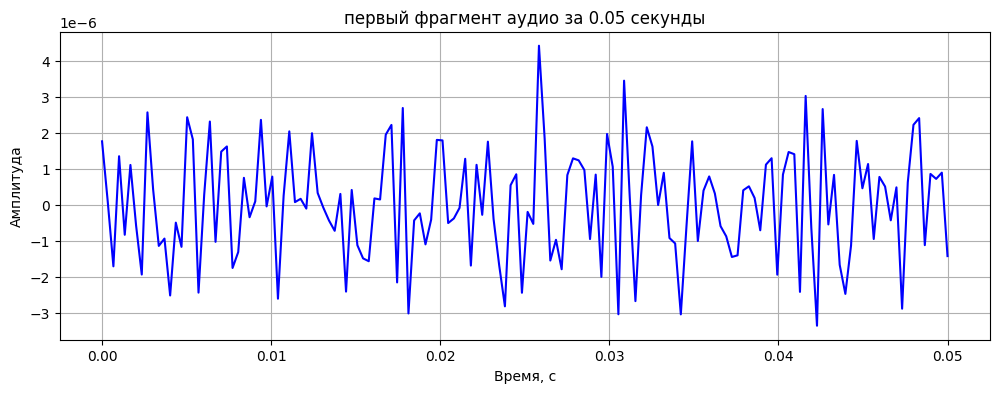

In [59]:
data, sample_rate = librosa.load("content/file1.wav", sr = 3000)
Audio(data, rate=sample_rate)

# График формы волны
plt.figure(figsize=(12, 4))
time = np.linspace(0, len(data) / sample_rate, num=len(data))
plt.plot(time, data, color='blue')
plt.title("Форма волны аудиофайла file1.wav")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

# График для деатльного рассмотрения 
duration = 0.05  # секунды
num_samples = int(duration * sample_rate)
data_segment = data[:num_samples]

time = np.linspace(0, duration, num=num_samples)

plt.figure(figsize=(12, 4))
plt.plot(time, data_segment, color='blue')
plt.title("первый фрагмент аудио за 0.05 секунды")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

In [67]:
import sounddevice as sd

sd.play(data, samplerate=1000)
sd.wait()

Плеер браузера не поддерживает частоту дискретизации ниже 3000, поэтому буду проверять при помощи функции воспроизведения аудио данных "sd.play", заметно что при частоте дискретизации начиная от 2000 уже совсем сложно различить слова

### 3. Чем .wav отличается от других кодеков, например .mp3 или .ogg?

Формат .wav хранит звук без сжатия, в виде исходных отсчётов сигнала, поэтому файлы большие, но качество максимально.
Форматы .mp3 и .ogg используют сжатие с потерями — уменьшают размер, удаляя звуки, малозаметные для слуха, из-за чего качество немного снижается, но файлы занимают гораздо меньше места.


* **.WAV** — хранит звук в несжатом виде (обычно PCM). Каждый отсчёт записан точно, без потерь данных. Качество оригинальное, но размер файла очень большт).
* **.MP3** — применяет сжатие с потерями. Удаляет неслышимые частоты и снижает точность, чтобы уменьшить размер. Качество зависит от битре/с).
* **.OGG** — также использует сжатие с потеbis), но обеспечивает лучшее качество звука при том же или меньшем размере, чем ве.**


# Задание 2. Гармонические сигналы (1 балл)

## Теория
[Гармонические колебания](https://ru.wikipedia.org/wiki/Гармонические_колебания) -  колебания, при которых физическая величина изменяется с течением времени по гармоническому (синусоидальному/косинусоидальному) закону. 

В общем случае гармонические колебания задаются формулой:

$$y=A \cos(\omega t+\varphi_0)$$

где $А$ - это амплитуда, $\omega$ – циклическая частота (радиан/с), $\varphi$ - фаза (сдвиг), $t$ – время. 


In [431]:
# Сначала определим функцию для отрисовки сигнала с хорошим масштабом и сеткой
# Это поможет легче анализировать сигнал
def draw_signal(data, figsize=(14, 14)):
    plt.figure(figsize=figsize)
    plt.plot(data, linewidth=2)
    plt.minorticks_on()
    plt.xticks(np.arange(0, 1000, step=100))
    plt.yticks(np.arange((data.min().round())//10*10, 
                         (data.max().round())//10*10+10, step=5))
    plt.grid(which='major',
        color = 'k', 
        linewidth = 1)
    plt.grid(which='minor', 
        color = 'k', 
        linestyle = ':')
    plt.show()

In [71]:
# Читаем данные с подготовленными сигналами
import pickle
with open("content/data.pickle", "rb") as f:
    test_data = pickle.load(f)
# Теперь можно приступать к практике!

## Практика

Постройте графики трех сигналов a, b и c из test_data['task2']. Попробуйте подобрать коэффициенты для этих сигналов. Сгенерируйте сигналы (1000 отсчетов) с подобранными коэффициентами. Постройте графики сгенерированных сигналов и пройдите тест на схожесть с оригинальным.


Подсказка. Фаза, период и амплитуда сигнала - целочисленные. Для генерации пользуйтесь библиотекой numpy и функциями arange, sin, cos.

### Сигнал ***a***

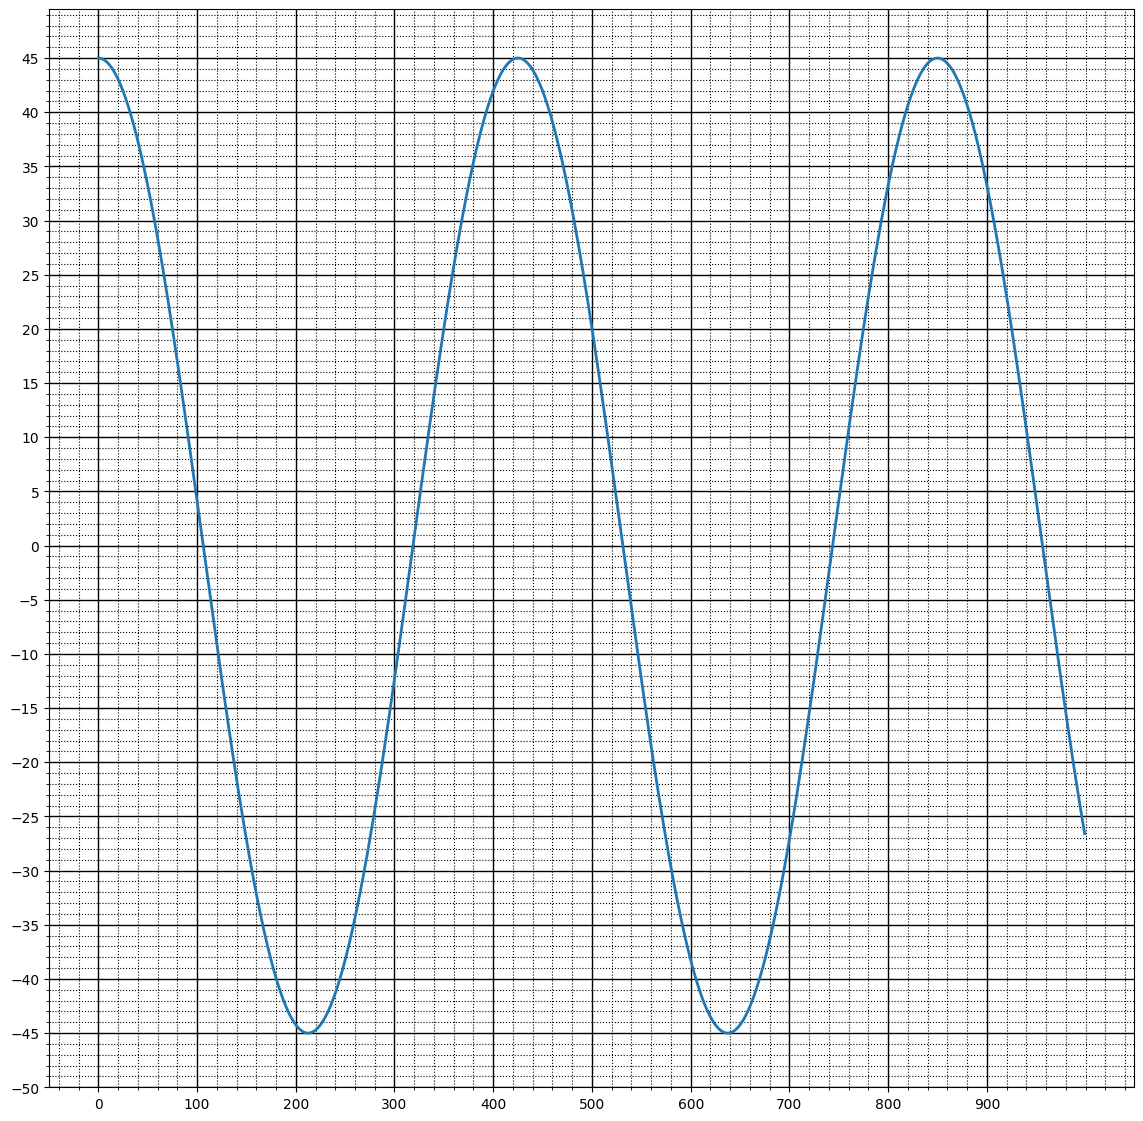

In [85]:
draw_signal(test_data['task2']['a'])

In [103]:
n = np.arange(1000)
A = 45 
T = 425    
phi = np.pi/2    
a = A * np.sin(2 * np.pi * n / T + phi)

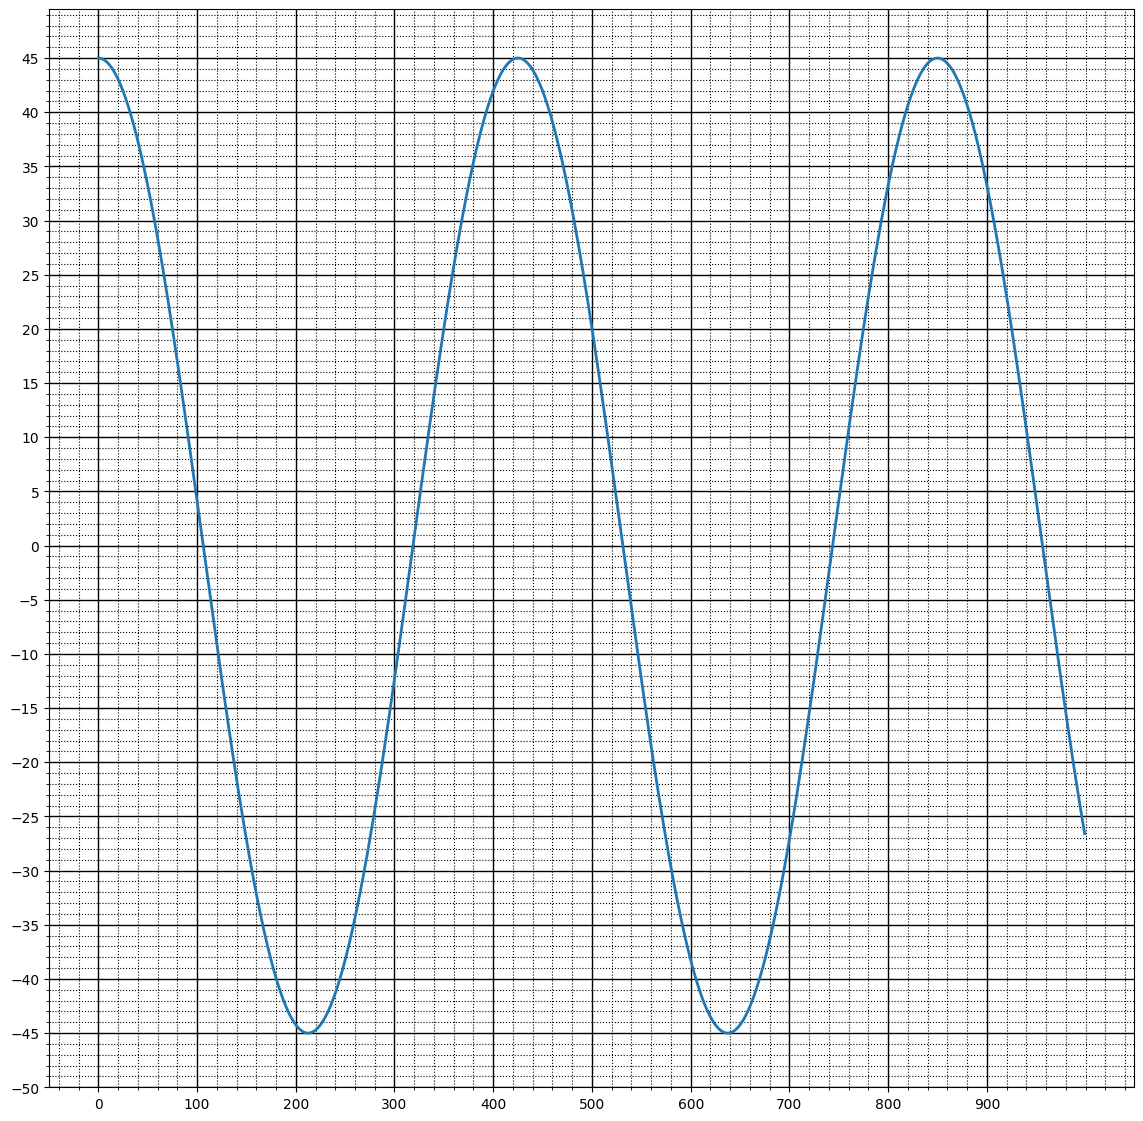

In [105]:
draw_signal(a)

In [107]:
assert len(a) == 1000
assert np.allclose(a, test_data["task2"]["a"], atol=1)
print("Ok!")

Ok!


**Подобранные коэффициенты для сигнала 'a':**

1. Амплитуда - $A= $ 45

2. Угловая частота ($ \displaystyle\omega =\frac{2\pi}{T}) = $ 425

3. Фаза - $\phi= $ pi/2

### Сигнал ***b***

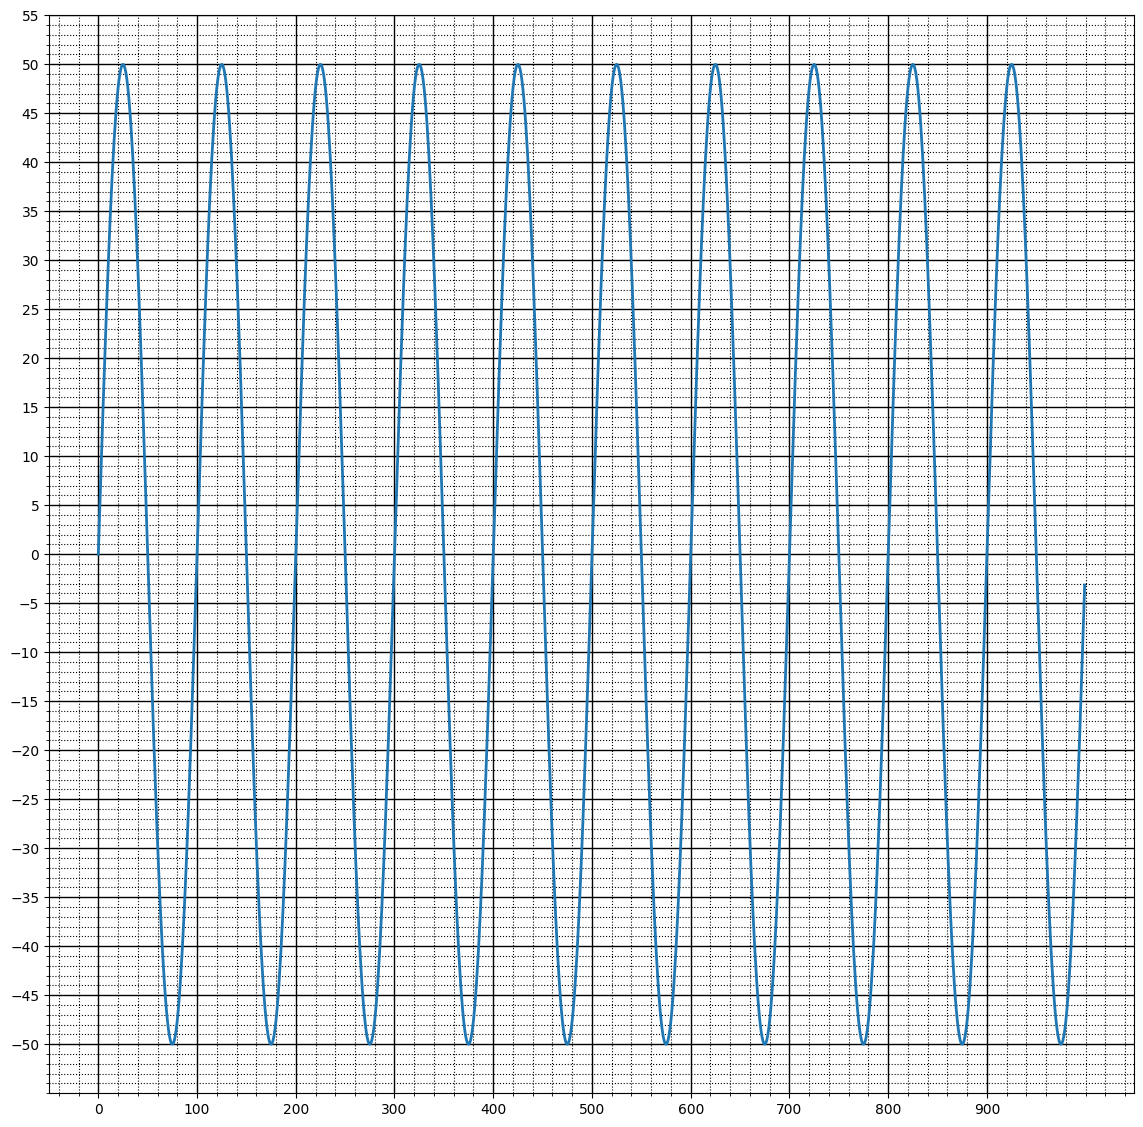

In [114]:
draw_signal(test_data['task2']['b'])

In [116]:
n = np.arange(1000)
A = 50
T = 100
phi = 0
b = A * np.sin(2*np.pi*n/T + phi)

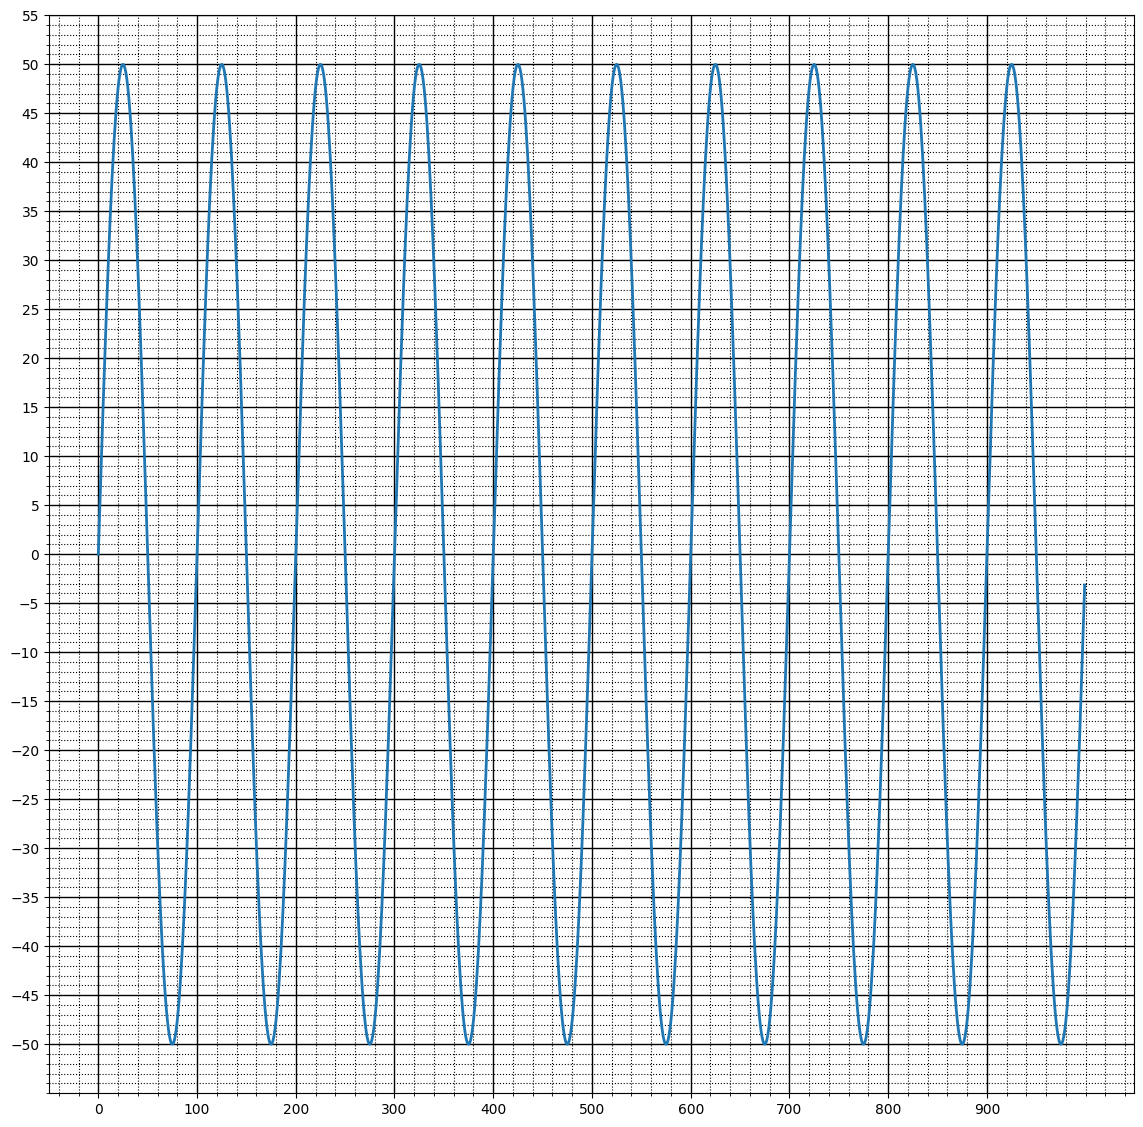

In [118]:
draw_signal(b)

In [120]:
assert len(b)== 1000
assert np.allclose(b, test_data["task2"]["b"], atol=1)
print("Ok!")

Ok!


**Подобранные коэффициенты для сигнала 'b':**

1. Амплитуда - $A= $ 100

2. Угловая частота ($ \displaystyle\omega =\frac{2\pi}{T}) = $ 50

3. Фаза - $\phi= $ 0

### Сигнал ***c***

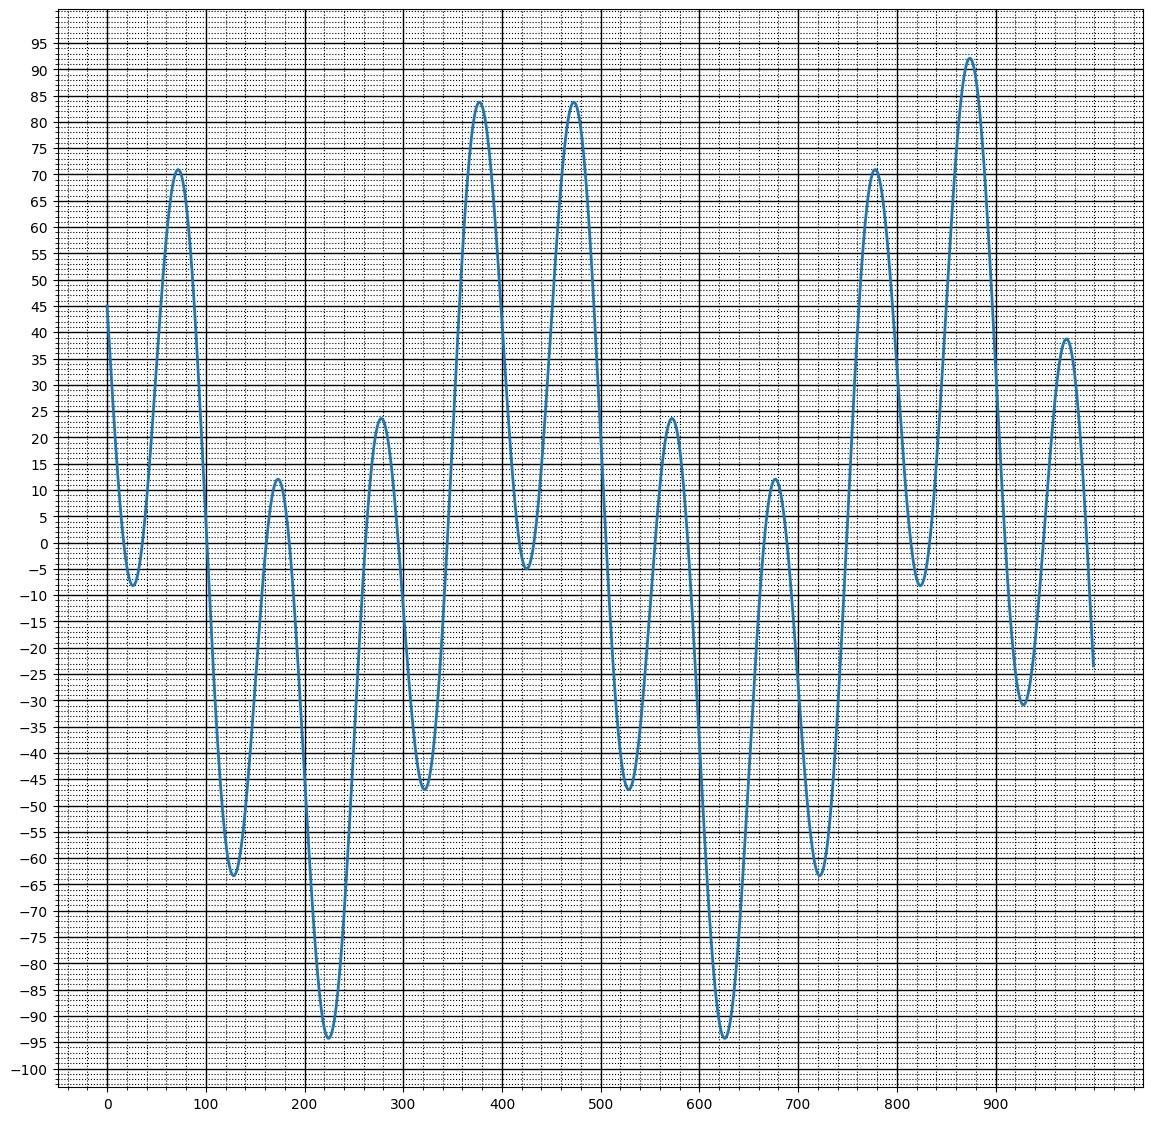

In [433]:
draw_signal(test_data['task2']['c'])

In [627]:
# сигнал состоит из двух гармоник
n = np.arange(1000)
A1 = 45
A2 = 49
T1 =  400
T2 = 100
phi1 = np.pi/2
phi2 = np.pi
c = A1* np.sin(2*np.pi*n/T1 + phi1) + A2 * np.sin(2*np.pi*n/T2 + phi2)

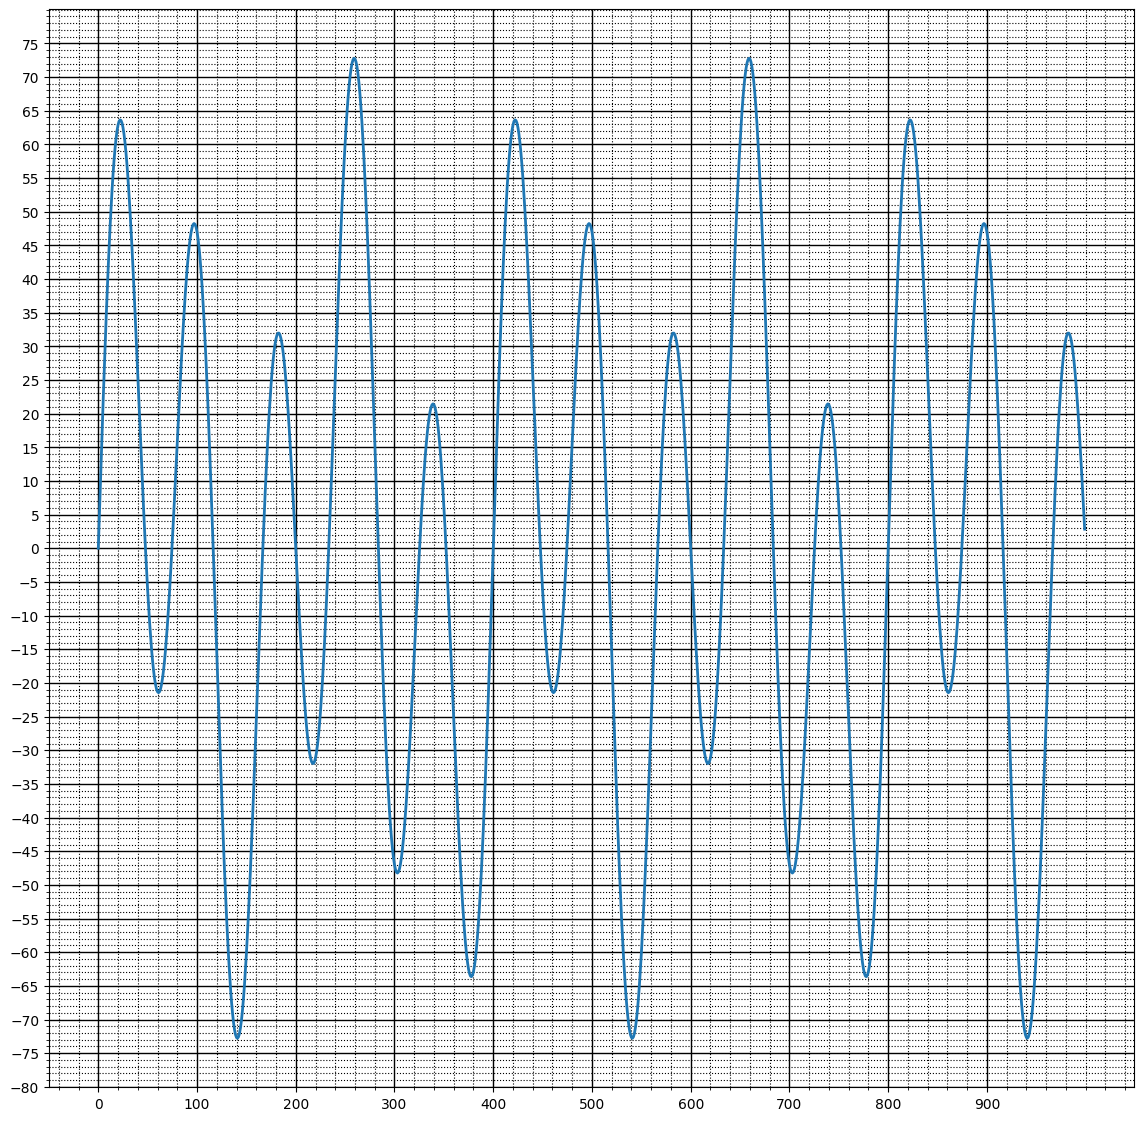

In [629]:
draw_signal(c)

In [631]:
assert len(c)== 1000
assert np.allclose(c, test_data["task2"]["c"], atol=1)
print("Ok!")

AssertionError: 

# Задание 3. Свертка (3 балла)

## Теория
Одна из наиболее частых операций, которая выполняется при обработке сигналов, это свёртка. Свёртка имеет много различных применений, например, с ее помощью можно убрать из сигнала шумы или применить к сигналу эффект эхо.


Свёртка — это математическая операция, применённая к двум функциям f и g и порождающая третью функцию. Операцию свёртки можно интерпретировать как «схожесть» одной функции с отражённой и сдвинутой копией другой.  Другими словами, преобразование свёртки однозначно определяет выходной сигнал y(t) для установленного значения входного сигнала x(t) при известном значении функции импульсного отклика системы h(t).

<!-- ![Convolution](resources/Convolution_of_box_signal_with_itself2.gif "Convolution") -->
![Convolution](resources/Convolution_of_box_signal_with_itself2.gif "Convolution")

Формула свёртки:
$$y_t=\frac{1}{2} \int_0^T x(\tau)h(t-τ)dτ$$
где $\tau$  - длительность импульсной переходной характеристики.

## Практика
Реализуйте операцию свёртки. Сравните её с существующей реализацией scipy.signal.convolve. Постройте графики фильтра, исходного сигнала и результата свертки.

In [225]:
def convolve(in1, in2):
    n = len(in1)
    m = len(in2)
    out = np.zeros(n + m - 1)
    
    for i in range(n):
        for j in range(m):
            out[i + j] += in1[i] * in2[j]
    return out

In [227]:
def test_convolve(a, b, print_debug=False):
    my_result = convolve(a, b)
    scipy_result = scipy.signal.convolve(a, b, method='direct')
    if print_debug:
        print(f"Your result {my_result}")
        print(f"Scipy result {scipy_result}")
    assert np.allclose(my_result, scipy_result), f"Test {a} conv {b} failed"
    print("Ok!")

In [241]:
a = np.repeat([0,1,0], 10)
b = np.array([0,1,2,3,2,1,0])

In [235]:
test_convolve(a, b, print_debug=False)

Ok!


### Нарисуйте результат свертки a и b

Сигнал **а**

In [272]:
plt.subplot(3, 1, 1)
plt.stem(range(len(a)), a)
plt.title("Сигнал a")
plt.ylabel("Амплитуда")

Text(0, 0.5, 'Амплитуда')

Сигнал **b**

In [275]:
plt.subplot(3, 1, 2)
plt.stem(range(len(b)), b)
plt.title("Сигнал b")
plt.ylabel("Амплитуда")

Text(0, 0.5, 'Амплитуда')

Свертка **a** и **b**

In [278]:
y = convolve(a, b)
plt.subplot(3, 1, 3)
plt.stem(range(len(y)), y)
plt.title("Свертка a и b")
plt.xlabel("n")
plt.ylabel("Амплитуда")

Text(0, 0.5, 'Амплитуда')

Все 3 графика на одной картинке:

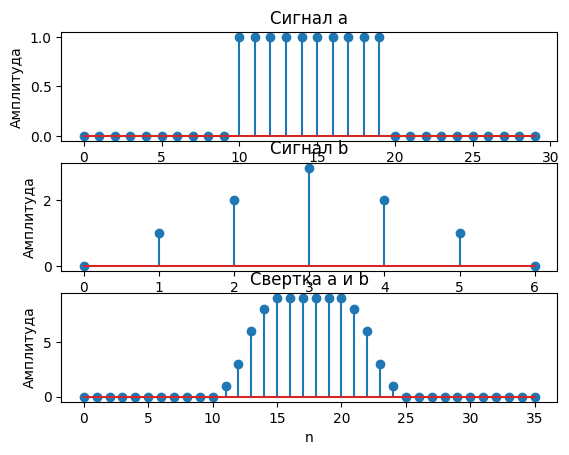

<Figure size 1000x600 with 0 Axes>

In [281]:
plt.figure(figsize=(10, 6))
plt.tight_layout()
plt.show()

# Задание 4. * Алгоритм Карплуса-Стронга 

Реализуйте  [Алгоритм Карплуса-Стронга](https://en.wikipedia.org/wiki/Karplus%E2%80%93Strong_string_synthesis). В качестве фильтра используйте усреднитель двух смежных отсчетов. Проверьте результат. 

Отрисуйте и воспроизведите полученный сигнал. На что влияют параметры генерации? Попробуйте имитировать звучание разных струн гитары.

In [513]:
def karplus_strong(noise, N):
    # Noise - input
    # N - number of samples to generate
    # return y - generated signal based on Noise 
    # YOUR CODE HERE
    raise NotImplementedError()
    

In [ ]:
np.random.seed(seed=1)
sample_rate = 44100 
frequency = 82.41
sec = 2
gen_len = sample_rate * sec
noise = (2 * np.random.uniform(-1, 1, int(sample_rate/frequency))) # [-1, 1]

gen_wav = karplus_strong(noise, gen_len)
assert np.allclose(gen_wav[:len(noise)], noise), "Generated signal must starting with noise"
assert np.allclose(gen_wav[len(noise)], (noise[0])/2), "Out of range samples eq 0."
assert np.allclose(gen_wav[len(noise)+1: 2*len(noise)], (noise[:-1] + noise[1:])/2), \
    "Bad requrent rule( 1 iteration)"
assert np.allclose(gen_wav[2*len(noise)], (noise[0]/2 + noise[-1])/2), \
    "Bad requrent rule( 2 iteration)"
assert np.allclose(gen_wav[2*len(noise)+2: 3*len(noise)], \
                   (((noise[:-1] + noise[1:])/2)[:-1] + ((noise[:-1] + noise[1:])/2)[1:])/2), \
    "Bad requrent rule( 3 iteration)"
print('All Ok!')

### Попробуем покрутить параметры генерации

Сгенерируем гитарные ноты:

In [ ]:
# YOUR CODE HERE

Визуализируем затухание амплитуды:

In [ ]:
plt.figure(figsize=(10,5))
plt.xlabel('n', fontsize=14)
plt.ylabel('Амплитуда', fontsize=14)
plt.xlim(0, gen_len)
plt.plot(np.linspace(0, gen_len+1, gen_len), gen_wav)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid()

Визуализируйте затухание амплитуд гитарных нот:

In [ ]:
# YOUR CODE HERE